In [62]:
# ÉTAPE 1 : IMPORTATION DES BIBLIOTHÈQUES

import numpy as np
import pandas as pd

# Scikit-learn : machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LassoCV  # Les modèles Lasso optimisés
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer

# Matplotlib : visualisation
import matplotlib.pyplot as plt

## Étape 2 : Chargement des données

In [63]:
# ÉTAPE 2 : CHARGEMENT DES DONNÉES

# Chargement des données d'entraînement
df_train = pd.read_csv('Data/train.csv')

# Chargement des données de test
df_test = pd.read_csv('Data/test.csv')

print("Données chargées avec succès !")
print(f"\nTaille des données d'entraînement : {df_train.shape}")
print(f"Taille des données de test : {df_test.shape}")
print("\nLes 5 premières lignes :")
print(df_train.head())

Données chargées avec succès !

Taille des données d'entraînement : (1460, 81)
Taille des données de test : (1459, 80)

Les 5 premières lignes :
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4    

## Étape 3 : Préparation et normalisation des données

In [ ]:
# 3.1 : Extraire la target (Y) et appliquer LOG TRANSFORMATION
# Log transformation réduit les valeurs extrêmes et améliore les résidus
# FORMULE : Y_log = log(Y + 1)  [+1 pour éviter log(0)]

Y = np.log1p(df_train[target_col].values)  # log1p = log(1 + x)
Y_original = df_train[target_col].values   # Garder les valeurs originales pour comparaison

print(f"\n✓ Target transformée (log)")
print(f"  - Target original (moyenne) : {Y_original.mean():,.2f}")
print(f"  - Target log (moyenne) : {Y.mean():,.4f}")
print(f"  - Min/Max original : {Y_original.min():,.2f} / {Y_original.max():,.2f}")
print(f"  - Min/Max log : {Y.min():,.4f} / {Y.max():,.4f}")

# 3.2 : Séparer features et cible
X_train_raw = df_train.drop(columns=[target_col])
X_test_raw = df_test.copy()

# IMPORTANT: Vérifier que SalePrice n'existe pas dans le test
if target_col in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[target_col])

print("✓ Données brutes séparées (X, Y)")

# 3.3 : Identifier features numériques et catégoriques
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeatures identifiées :")
print(f"  - Numériques : {len(numeric_features)} colonnes")
print(f"  - Catégoriques : {len(categorical_features)} colonnes")

# 3.4 : Créer le préprocesseur avec ColumnTransformer et Pipeline
# ColumnTransformer permet de traiter différemment les colonnes numériques et catégoriques

# Pipeline pour les features numériques
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline pour les features catégoriques
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='float64'))
])

# Combiner les deux pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Préprocesseur créé (ColumnTransformer + OneHotEncoder)")

# 3.5 : Appliquer le préprocesseur aux données
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

print(f"\nDonnées transformées")
print(f"  - X_train_processed shape : {X_train_processed.shape}")
print(f"  - X_test_processed shape : {X_test_processed.shape}")

# 3.6 : Remplacer les NaN par 0 (ce sont les catégories inconnues)
X_train_processed = np.nan_to_num(X_train_processed, nan=0.0)
X_test_processed = np.nan_to_num(X_test_processed, nan=0.0)

# 3.6b : Vérifier qu'il n'y a pas de NaN
nan_count_train = np.isnan(X_train_processed).sum()
nan_count_test = np.isnan(X_test_processed).sum()
print(f"  - NaN dans X_train après nan_to_num : {nan_count_train}")
print(f"  - NaN dans X_test après nan_to_num : {nan_count_test}")

# 3.7 : Split train/validation
# Nous séparons en 2 parties : entraînement (2/3) et validation (1/3)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_processed, Y, test_size=1/3, random_state=42)
    
print(f"\nDimensions finales :")
print(f"  - X_train : {X_train.shape}")
print(f"  - Y_train : {Y_train.shape}")
print(f"  - X_val : {X_val.shape}")
print(f"  - Y_val : {Y_val.shape}")
print(f"  - X_test : {X_test_processed.shape}")

# 3.8 : Créer le scorer RMSLE personnalisé
def rmsle(y_true, y_pred):
    """
    Calcule le Root Mean Squared Log Error (RMSLE)
    RMSLE = sqrt(mean((log(y_pred+1) - log(y_true+1))²))
    """
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# Créer un scorer pour la validation croisée
rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

print("\nScorer RMSLE créé pour la validation croisée")
print("="*70)


✓ Target transformée (log)
  - Target original (moyenne) : 180,921.20
  - Target log (moyenne) : 12.0241
  - Min/Max original : 34,900.00 / 755,000.00
  - Min/Max log : 10.4603 / 13.5345
✓ Données brutes séparées (X, Y)

Features identifiées :
  - Numériques : 37 colonnes
  - Catégoriques : 43 colonnes
✓ Préprocesseur créé (ColumnTransformer + OneHotEncoder)

✓ Données transformées
  - X_train_processed shape : (1460, 304)
  - X_test_processed shape : (1459, 304)
  - NaN dans X_train après nan_to_num : 0
  - NaN dans X_test après nan_to_num : 0

Dimensions finales :
  - X_train : (973, 304)
  - Y_train : (973,)
  - X_val : (487, 304)
  - Y_val : (487,)
  - X_test : (1459, 304)

✓ Scorer RMSLE créé pour la validation croisée


C:\Users\Digi\AppData\Local\Temp\ipykernel_14608\4195674503.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()


## Étape 4 : Entraînement avec LassoCV (recherche du meilleur alpha)

### Qu'est-ce que LassoCV ?
**LassoCV** = Lasso + Cross-Validation

Au lieu de devoir choisir manuellement le paramètre `alpha` (force de régularisation),
LassoCV teste automatiquement plusieurs valeurs et trouve la meilleure grâce à la validation croisée.

In [65]:
# ============================================
# ÉTAPE 4 : ENTRAÎNEMENT AVEC VALIDATION CROISÉE (5-FOLD CV)
# ============================================
# QU'EST-CE QUE C'EST ?
# La validation croisée nous permet de :
# 1. Trouver le meilleur alpha
# 2. Estimer la performance réelle du modèle sur des données non vues
# POURQUOI ?
# Pour éviter l'overfitting et avoir une évaluation honnête

print("="*70)
print("ÉTAPE 4 : ENTRAÎNEMENT AVEC VALIDATION CROISÉE (5-FOLD)")
print("="*70)

# Définir les alphas à tester
alphas = np.logspace(-3, 3, 50)

# Créer le modèle LassoCV avec validation croisée
# Note: LassoCV utilise MSE par défaut
print("\nEntraînement du modèle avec LassoCV (5-fold CV)...\n")

lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    random_state=42,
    max_iter=10000,
    n_jobs=-1  # Utiliser tous les cores disponibles
)

# Entraîner le modèle
lasso_cv.fit(X_train, Y_train)

# Calculer les scores RMSLE avec cross_val_score
from sklearn.model_selection import cross_val_score
cv_scores_rmsle = -cross_val_score(
    Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=10000),
    X_train, 
    Y_train,
    cv=5,
    scoring=rmsle_scorer
)

# Afficher les résultats
print(f"\nMeilleur alpha trouvé : {lasso_cv.alpha_:.4f}")
print(f"Meilleur score RMSLE (moyenne 5-fold) : {cv_scores_rmsle.mean():.4f}")
print(f"Écart-type RMSLE : {cv_scores_rmsle.std():.4f}")

print("\nScores RMSLE par fold :")
for i, score in enumerate(cv_scores_rmsle, 1):
    print(f"  Fold {i} : {score:.4f}")
print(f"Moyenne RMSLE (cross-val) : {cv_scores_rmsle.mean():.4f}")
print(f"Écart-type : {cv_scores_rmsle.std():.4f}")

print("\n" + "="*70)
print("RÉENTRAÎNEMENT DU MODÈLE FINAL")
print("="*70)
print("Réentraînement du modèle final avec toutes les données...\n")

lasso_final = Lasso(
    alpha=lasso_cv.alpha_,
    random_state=42,
    max_iter=10000
)

lasso_final.fit(X_train, Y_train)

print("✓ Modèle final entraîné avec le meilleur alpha !")

# Afficher les propriétés du modèle
non_zero_coef = np.sum(lasso_final.coef_ != 0)
total_coef = len(lasso_final.coef_)
sparsity = (total_coef - non_zero_coef) / total_coef * 100

print(f"\nPropriétés du modèle :")
print(f"  - Coefficients non-zéro : {non_zero_coef} / {total_coef}")
print(f"  - Coefficients à zéro : {total_coef - non_zero_coef}")
print(f"  - Sparsité : {sparsity:.2f}%")
print(f"  - Intercept (biais) : {lasso_final.intercept_:.4f}")

ÉTAPE 4 : ENTRAÎNEMENT AVEC VALIDATION CROISÉE (5-FOLD)

Entraînement du modèle avec LassoCV (5-fold CV)...


Meilleur alpha trouvé : 0.0010
Meilleur score RMSLE (moyenne 5-fold) : 0.0123
Écart-type RMSLE : 0.0025

Scores RMSLE par fold :
  Fold 1 : 0.0116
  Fold 2 : 0.0153
  Fold 3 : 0.0117
  Fold 4 : 0.0083
  Fold 5 : 0.0146
Moyenne RMSLE (cross-val) : 0.0123
Écart-type : 0.0025

RÉENTRAÎNEMENT DU MODÈLE FINAL
Réentraînement du modèle final avec toutes les données...

✓ Modèle final entraîné avec le meilleur alpha !

Propriétés du modèle :
  - Coefficients non-zéro : 100 / 304
  - Coefficients à zéro : 204
  - Sparsité : 67.11%
  - Intercept (biais) : 11.9162

Meilleur alpha trouvé : 0.0010
Meilleur score RMSLE (moyenne 5-fold) : 0.0123
Écart-type RMSLE : 0.0025

Scores RMSLE par fold :
  Fold 1 : 0.0116
  Fold 2 : 0.0153
  Fold 3 : 0.0117
  Fold 4 : 0.0083
  Fold 5 : 0.0146
Moyenne RMSLE (cross-val) : 0.0123
Écart-type : 0.0025

RÉENTRAÎNEMENT DU MODÈLE FINAL
Réentraînement du modèl

## Étape 5 : Prédictions et évaluation

In [66]:
# ============================================
# ÉTAPE 5 : PRÉDICTIONS ET ÉVALUATION AVEC RMSLE
# ============================================
# QU'EST-CE QUE C'EST ?
# Générer des prédictions et évaluer la performance du modèle avec plusieurs métriques
# POURQUOI ?
# Pour voir à quel point le modèle s'est amélioré avec le meilleur alpha
# Et comparer différentes métriques d'erreur

# Générer les prédictions
Y_train_pred = lasso_final.predict(X_train)
Y_val_pred = lasso_final.predict(X_val)

# Calculer les métriques
train_mse = mean_squared_error(Y_train, Y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(Y_train, Y_train_pred)
train_r2 = r2_score(Y_train, Y_train_pred)
train_rmsle_val = rmsle(Y_train, Y_train_pred)

val_mse = mean_squared_error(Y_val, Y_val_pred)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(Y_val, Y_val_pred)
val_r2 = r2_score(Y_val, Y_val_pred)
val_rmsle_val = rmsle(Y_val, Y_val_pred)

# Afficher les résultats
print("="*70)
print("ÉVALUATION - ENSEMBLE D'ENTRAÎNEMENT (LOG SCALE)")
print("="*70)
print(f"MSE (Mean Squared Error)       : {train_mse:,.2f}")
print(f"RMSE (Root MSE)                : {train_rmse:,.2f}")
print(f"RMSLE (Root MSE Log Error)     : {train_rmsle_val:.4f}")
print(f"MAE (Mean Absolute Error)      : {train_mae:,.2f}")
print(f"R² Score                       : {train_r2:.4f}")

print("\n" + "="*70)
print("ÉVALUATION - ENSEMBLE DE VALIDATION (LOG SCALE)")
print("="*70)
print(f"MSE (Mean Squared Error)       : {val_mse:,.2f}")
print(f"RMSE (Root MSE)                : {val_rmse:,.2f}")
print(f"RMSLE (Root MSE Log Error)     : {val_rmsle_val:.4f}")
print(f"MAE (Mean Absolute Error)      : {val_mae:,.2f}")
print(f"R² Score                       : {val_r2:.4f}")

# Comparaison train vs validation
print("\n" + "="*70)
print("Overfitting ?")
print("="*70)
diff = train_r2 - val_r2
print(f"Différence R² (train - val) : {diff:.4f}")
if diff > 0.1:
    print("⚠️  Possible overfitting détecté")
else:
    print("✓ Pas de overfitting significatif")

# Afficher quelques prédictions
print("\n" + "="*70)
print("EXEMPLES DE PRÉDICTIONS (Validation - Log Scale)")
print("="*70)

pred_data = []
for i in range(min(5, len(Y_val))):
    pred = Y_val_pred[i]
    real = Y_val[i]
    error = pred - real
    pct_error = (abs(error) / abs(real) * 100) if real != 0 else 0
    pred_data.append([i+1, f"{pred:.4f}", f"{real:.4f}", f"{error:.4f}", f"{pct_error:.2f}%"])

print(f"{'Prédiction (log)':>20} | {'Vraie Valeur (log)':>20} | {'Erreur (log)':>20} | {'% Erreur':>10}")
print("-" * 75)
for row in pred_data:
    print(f"{row[1]:>20} | {row[2]:>20} | {row[3]:>20} | {row[4]:>10}")


ÉVALUATION - ENSEMBLE D'ENTRAÎNEMENT (LOG SCALE)
MSE (Mean Squared Error)       : 0.01
RMSE (Root MSE)                : 0.12
RMSLE (Root MSE Log Error)     : 0.0091
MAE (Mean Absolute Error)      : 0.08
R² Score                       : 0.9107

ÉVALUATION - ENSEMBLE DE VALIDATION (LOG SCALE)
MSE (Mean Squared Error)       : 0.02
RMSE (Root MSE)                : 0.13
RMSLE (Root MSE Log Error)     : 0.0105
MAE (Mean Absolute Error)      : 0.10
R² Score                       : 0.8932

Overfitting ?
Différence R² (train - val) : 0.0175
✓ Pas de overfitting significatif

EXEMPLES DE PRÉDICTIONS (Validation - Log Scale)
    Prédiction (log) |   Vraie Valeur (log) |         Erreur (log) |   % Erreur
---------------------------------------------------------------------------
             11.9324 |              11.9480 |              -0.0155 |      0.13%
             12.6618 |              12.6916 |              -0.0298 |      0.23%
             11.5837 |              11.6527 |              -0.

## Étape 6 : Visualisations

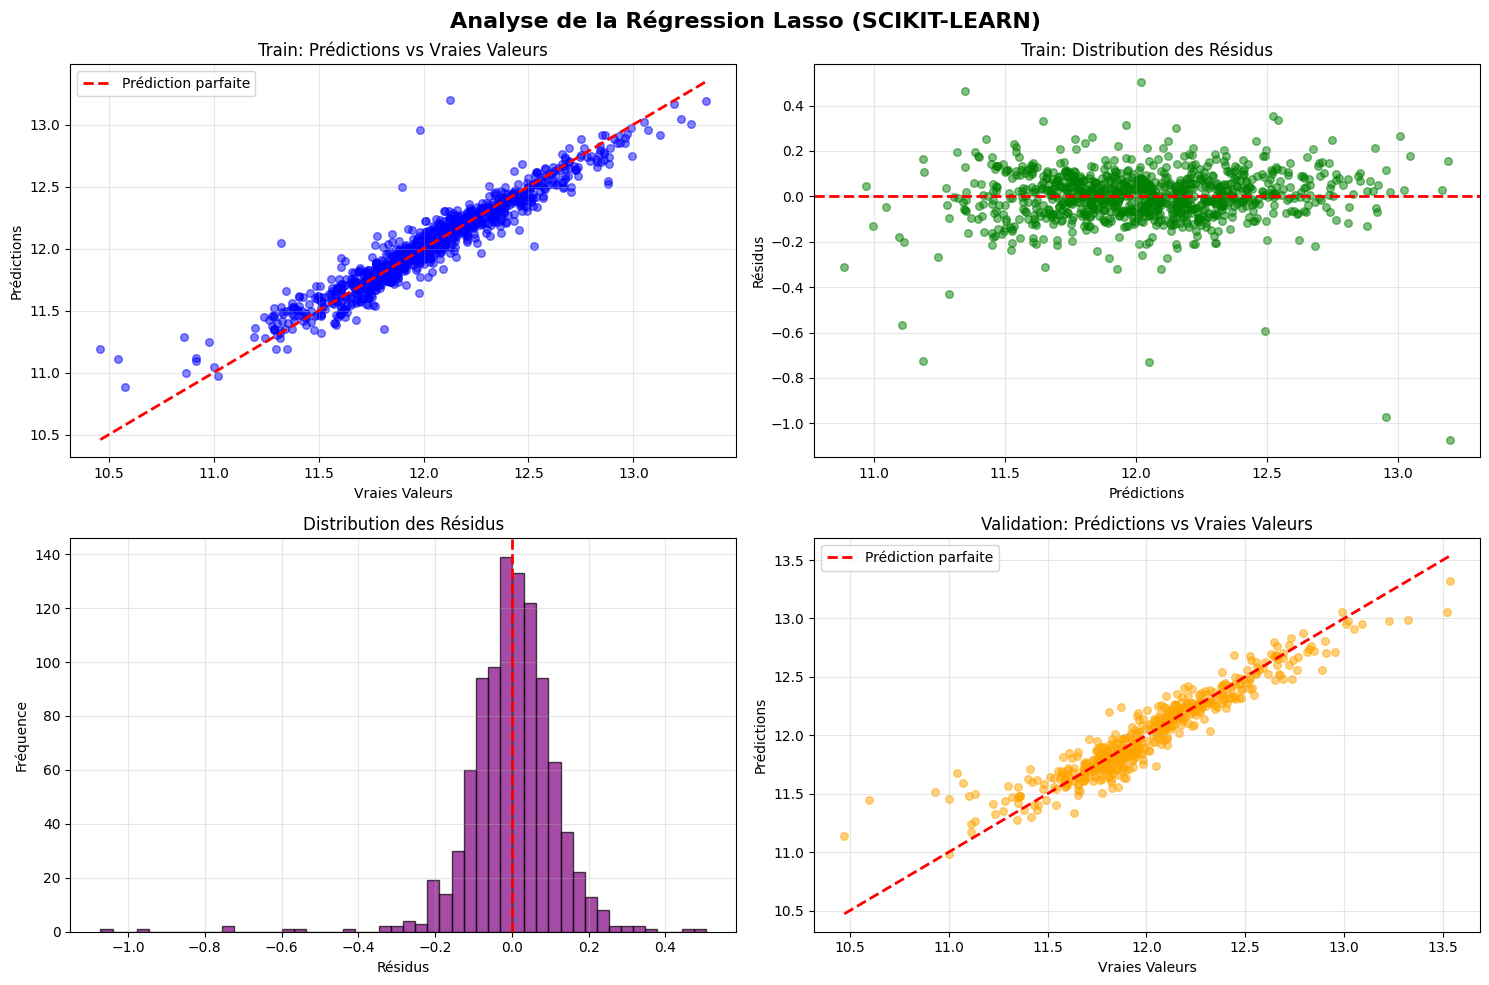

In [67]:
# ============================================
# ÉTAPE 6 : VISUALISATIONS
# ============================================
# QU'EST-CE QUE C'EST ?
# Créer des graphiques pour mieux comprendre la performance
# POURQUOI ?
# Les graphiques permettent de visualiser rapidement comment le modèle fonctionne

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Analyse de la Régression Lasso (SCIKIT-LEARN)', fontsize=16, fontweight='bold')

# 1. Prédictions vs Vraies Valeurs (Entraînement)
ax1 = axes[0, 0]
ax1.scatter(Y_train, Y_train_pred, alpha=0.5, s=30, color='blue')
min_val = min(Y_train.min(), Y_train_pred.min())
max_val = max(Y_train.max(), Y_train_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction parfaite')
ax1.set_xlabel('Vraies Valeurs')
ax1.set_ylabel('Prédictions')
ax1.set_title('Train: Prédictions vs Vraies Valeurs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Résidus (Entraînement)
ax2 = axes[0, 1]
residuals = Y_train - Y_train_pred
ax2.scatter(Y_train_pred, residuals, alpha=0.5, s=30, color='green')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Prédictions')
ax2.set_ylabel('Résidus')
ax2.set_title('Train: Distribution des Résidus')
ax2.grid(True, alpha=0.3)

# 3. Histogramme des résidus
ax3 = axes[1, 0]
ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Résidus')
ax3.set_ylabel('Fréquence')
ax3.set_title('Distribution des Résidus')
ax3.grid(True, alpha=0.3)

# 4. Prédictions vs Vraies Valeurs (Validation)
ax4 = axes[1, 1]
ax4.scatter(Y_val, Y_val_pred, alpha=0.5, s=30, color='orange')
min_val = min(Y_val.min(), Y_val_pred.min())
max_val = max(Y_val.max(), Y_val_pred.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prédiction parfaite')
ax4.set_xlabel('Vraies Valeurs')
ax4.set_ylabel('Prédictions')
ax4.set_title('Validation: Prédictions vs Vraies Valeurs')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Étape 7 : Analyse des coefficients (Features importantes)

TOP 10 FEATURES QUI AUGMENTENT LE PRIX (Coefficients positifs)
             Feature  Coefficient
Neighborhood_Crawfor     0.102989
Neighborhood_StoneBr     0.094741
         OverallQual     0.090955
           GrLivArea     0.089595
 Exterior1st_BrkFace     0.084862
Neighborhood_NridgHt     0.057296
         BsmtQual_Ex     0.056518
     BsmtExposure_Gd     0.054718
     Condition1_Norm     0.051435
          GarageCars     0.047515

TOP 10 FEATURES QUI DIMINUENT LE PRIX (Coefficients négatifs)
              Feature  Coefficient
     RoofMatl_ClyTile    -0.404660
      LandContour_Bnk    -0.059529
      Condition2_PosN    -0.057790
          MSZoning_RM    -0.057300
SaleCondition_Abnorml    -0.045353
         CentralAir_N    -0.044987
 Neighborhood_Edwards    -0.030864
     BsmtFinType1_Unf    -0.030398
       BldgType_Twnhs    -0.029948
           MSSubClass    -0.028367

TOP 15 FEATURES PAR MAGNITUDE (valeur absolue du coefficient)
              Feature  Coefficient
     RoofMatl_Cly

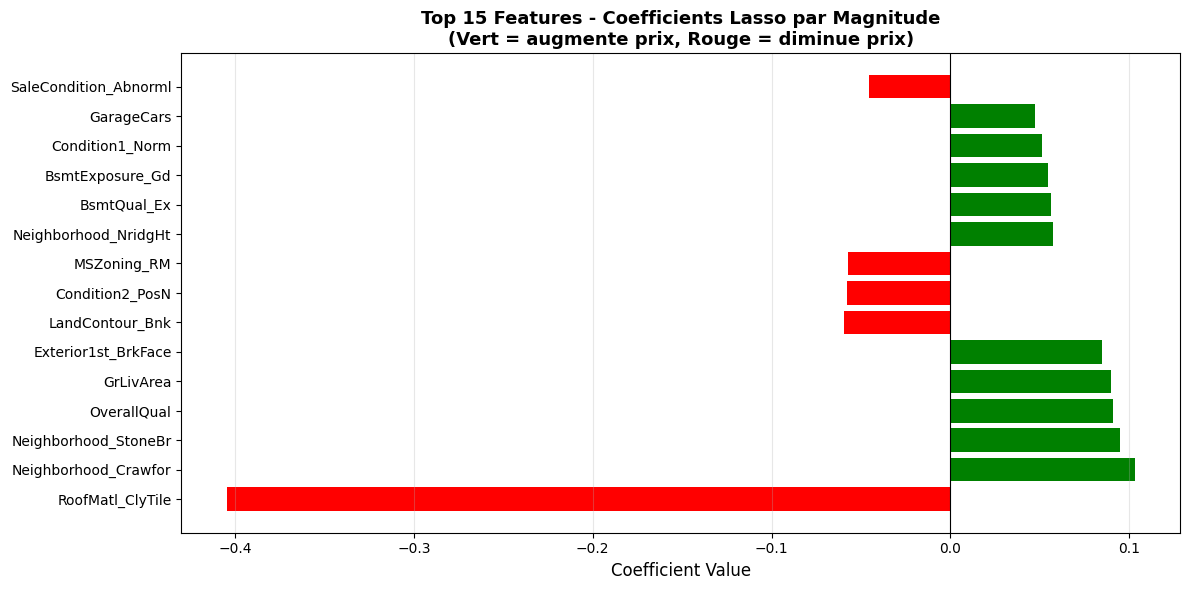


SÉLECTION DE FEATURES PAR LASSO
Coefficients utilisés (non-zéro) : 100
  - Positifs (augmentent prix) : 58
  - Négatifs (diminuent prix) : 42
Coefficients ignorés (zéro) : 204

Cela montre que Lasso a fait une SÉLECTION DE FEATURES :
Elle a supprimé 204 features non pertinentes !


In [68]:
# ============================================
# ÉTAPE 7 : ANALYSE DES COEFFICIENTS (Features importantes)
# ============================================
# QU'EST-CE QUE C'EST ?
# Afficher les coefficients (poids) du modèle pour voir les features les plus importantes
# POURQUOI ?
# Les coefficients indiquent l'importance de chaque feature
# Un coefficient positif = augmente le prix
# Un coefficient négatif = diminue le prix
# Un coefficient zéro = feature ignorée par Lasso (sélection de features !)

# Récupérer les noms des features après transformation
# POURQUOI ?
# Après le OneHotEncoder, les noms de colonnes ont changé
# On doit les récupérer depuis le préprocesseur

feature_names = []

# Features numériques
for name in numeric_features:
    feature_names.append(name)

# Features catégoriques (après OneHotEncoding)
categorical_transformer = preprocessor.named_transformers_['cat']
onehot_encoder = categorical_transformer.named_steps['onehot']

for idx, cat_feature in enumerate(categorical_features):
    categories = onehot_encoder.categories_[idx]
    for category in categories:
        feature_names.append(f"{cat_feature}_{category}")

# Créer un DataFrame avec les coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_final.coef_
})

# Ajouter la valeur absolue du coefficient
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])

# ========== ANALYSE 1 : FEATURES AVEC IMPACT POSITIF (qui augmentent le prix) ==========
print("="*70)
print("TOP 10 FEATURES QUI AUGMENTENT LE PRIX (Coefficients positifs)")
print("="*70)
coef_df_positive = coef_df[coef_df['Coefficient'] > 0].sort_values('Coefficient', ascending=False).head(10)
print(coef_df_positive[['Feature', 'Coefficient']].to_string(index=False))

# ========== ANALYSE 2 : FEATURES AVEC IMPACT NÉGATIF (qui diminuent le prix) ==========
print("\n" + "="*70)
print("TOP 10 FEATURES QUI DIMINUENT LE PRIX (Coefficients négatifs)")
print("="*70)
coef_df_negative = coef_df[coef_df['Coefficient'] < 0].sort_values('Coefficient', ascending=True).head(10)
print(coef_df_negative[['Feature', 'Coefficient']].to_string(index=False))

# ========== ANALYSE 3 : VISUALISATION PAR MAGNITUDE ABSOLUE ==========
print("\n" + "="*70)
print("TOP 15 FEATURES PAR MAGNITUDE (valeur absolue du coefficient)")
print("="*70)
coef_df_sorted = coef_df.nlargest(15, 'Abs_Coefficient')
print(coef_df_sorted[['Feature', 'Coefficient']].to_string(index=False))

# Visualiser les coefficients
fig, ax = plt.subplots(figsize=(12, 6))

# Créer des couleurs différentes pour positif/négatif
colors = ['green' if x > 0 else 'red' for x in coef_df_sorted['Coefficient']]

# Créer le graphique
ax.barh(range(len(coef_df_sorted)), coef_df_sorted['Coefficient'], color=colors)
ax.set_yticks(range(len(coef_df_sorted)))
ax.set_yticklabels(coef_df_sorted['Feature'], fontsize=10)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Features - Coefficients Lasso par Magnitude\n(Vert = augmente prix, Rouge = diminue prix)', 
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', lw=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Statistiques sur la sparsité
print("\n" + "="*70)
print("SÉLECTION DE FEATURES PAR LASSO")
print("="*70)
non_zero_count = np.sum(coef_df['Coefficient'] != 0)
zero_count = np.sum(coef_df['Coefficient'] == 0)
positive_count = np.sum(coef_df['Coefficient'] > 0)
negative_count = np.sum(coef_df['Coefficient'] < 0)

print(f"Coefficients utilisés (non-zéro) : {non_zero_count}")
print(f"  - Positifs (augmentent prix) : {positive_count}")
print(f"  - Négatifs (diminuent prix) : {negative_count}")
print(f"Coefficients ignorés (zéro) : {zero_count}")
print(f"\nCela montre que Lasso a fait une SÉLECTION DE FEATURES :")
print(f"Elle a supprimé {zero_count} features non pertinentes !")


## Étape 8 : Prédictions finales

In [ ]:
# ============================================
# ÉTAPE 8 : PRÉDICTIONS FINALES ET SOUMISSION KAGGLE
# ============================================
# QU'EST-CE QUE C'EST ?
# Utiliser le modèle entraîné pour générer les prédictions finales
# POURQUOI ?
# Pour participer au concours Kaggle et soumettre les résultats

# Générer les prédictions finales sur le dataset test
Y_test_pred_log = lasso_final.predict(X_test_processed)

# Convertir les prédictions log back à l'échelle originale
# FORMULE INVERSE : Y = exp(Y_log) - 1
Y_test_pred = np.expm1(Y_test_pred_log)

print("\n" + "="*70)
print("PRÉDICTIONS FINALES")
print("="*70)
print(f"Prédictions générées : {len(Y_test_pred)}")
print(f"Min : {Y_test_pred.min():,.2f}")
print(f"Max : {Y_test_pred.max():,.2f}")
print(f"Moyenne : {Y_test_pred.mean():,.2f}")

print("\n" + "="*70)
print("PRÉPARATION DE LA SOUMISSION KAGGLE")
print("="*70)

# Récupérer les IDs du dataset de test
if 'Id' in df_test.columns:
    test_ids = df_test['Id'].values
else:
    # Si pas de colonne 'Id', créer une numérotation
    test_ids = np.arange(len(Y_test_pred))

# Créer le DataFrame de soumission
submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': Y_test_pred
})

print(f"\nFormat de soumission Kaggle :")
print(submission_df.head(10).to_string())

# Sauvegarder
output_filename = 'submission_lasso_kaggle.csv'
submission_df.to_csv(output_filename, index=False)
print(f"\n✓ Fichier prêt pour Kaggle : {output_filename}")

# Résumé final
print("\n" + "="*70)
print("RÉSUMÉ - RÉGRESSION LASSO SCIKIT-LEARN (HOUSE PRICES)")
print("="*70)

print(f"\nHyperparamètres finaux :")
print(f"  - Alpha (trouvé par LassoCV) : {lasso_cv.alpha_:.6f}")
print(f"  - Max iterations : 10000")
print(f"  - Cross-Validation folds : 5")
print(f"\nPerformance (Validation Set) :")
print(f"  - R² : {val_r2:.4f}")
print(f"  - RMSE : {val_rmse:,.2f}")
print(f"  - RMSLE : {val_rmsle_val:.4f}")
print(f"  - MAE : {val_mae:,.2f}")
print(f"\nCross-Validation avec RMSLE :")
print(f"  - Moyenne : {cv_scores_rmsle.mean():.4f}")
print(f"  - Écart-type : {cv_scores_rmsle.std():.4f}")
print(f"\nSélection de features :")
print(f"  - Features utilisées : {non_zero_coef}")
print(f"  - Features supprimées : {total_coef - non_zero_coef}")
print(f"  - Sparsité : {sparsity:.2f}%")
print(f"\nArchitecture du Pipeline :")
print(f"  - Préprocesseur : ColumnTransformer")
print(f"    • Numériques : StandardScaler")
print(f"    • Catégoriques : OneHotEncoder")
print(f"  - Modèle : Lasso (alpha optimisé par LassoCV)")
print(f"  - Métrique de validation : RMSLE (via make_scorer)")
print(f"\nSoumission Kaggle :")
print(f"  - Prédictions : {len(Y_test_pred)}")
print(f"  - Fichier : {output_filename}")



PRÉDICTIONS FINALES
Prédictions générées : 1459
Min : 58,280.38
Max : 685,826.18
Moyenne : 175,613.57

PRÉPARATION DE LA SOUMISSION KAGGLE

Format de soumission Kaggle :
     Id      SalePrice
0  1461  113653.554448
1  1462  134841.511716
2  1463  169098.793748
3  1464  196361.960366
4  1465  200132.673871
5  1466  172149.898052
6  1467  188740.721667
7  1468  165191.722265
8  1469  203492.694119
9  1470  117305.268388

✓ Fichier prêt pour Kaggle : submission_lasso_kaggle_v2.csv

RÉSUMÉ - RÉGRESSION LASSO SCIKIT-LEARN (HOUSE PRICES)

Hyperparamètres finaux :
  - Alpha (trouvé par LassoCV) : 0.001000
  - Max iterations : 10000
  - Cross-Validation folds : 5

Performance (Validation Set) :
  - R² : 0.8932
  - RMSE : 0.13
  - RMSLE : 0.0105
  - MAE : 0.10

Cross-Validation avec RMSLE :
  - Moyenne : 0.0123
  - Écart-type : 0.0025

Sélection de features :
  - Features utilisées : 100
  - Features supprimées : 204
  - Sparsité : 67.11%

Architecture du Pipeline :
  - Préprocesseur : Column